# Q8: Results

**Phase 9:** Results & Insights  
**Points: 3 points**

**Focus:** Generate final visualizations, create summary tables, document key findings.

**Lecture Reference:** Lecture 11, Notebook 4 ([`11/demo/04_modeling_results.ipynb`](https://github.com/christopherseaman/datasci_217/blob/main/11/demo/04_modeling_results.ipynb)), Phase 9. Also see Lecture 07 (visualization).

---

## Setup

In [81]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Load model results from Q7
predictions = pd.read_csv('output/q7_predictions.csv')
metrics = open('output/q7_model_metrics.txt').read()
feature_importance = pd.read_csv('output/q7_feature_importance.csv')

In [82]:
# get info from model_metrics.txt file 

model_metrics = {}

with open("output/q7_model_metrics.txt", "r") as f:
    lines = f.readlines()[3:]

for line in lines:
    line = line.strip()
    if not line:
        continue
    if line.endswith(":") and line.isupper():
        current_model = line[:-1].replace(" ", "_").lower()
        model_metrics[current_model] = {}
    else:
        parts = line.split(":")
        metric_name = parts[0].strip().lower().replace(" ", "_")
        value = float(parts[1].strip())
        model_metrics[current_model][metric_name] = value

metrics_df = pd.DataFrame(model_metrics)
print(metrics_df)

metrics_summary_df = metrics_df.reset_index().rename(columns={'index':'metric'})

metrics_summary_df.to_csv('output/q8_summary.csv', index=False)
print('saved model performances to summary csv!')

            linear_regression  random_forest  xgboost
train_r^2              0.6504         0.9871   0.8725
test_r^2               0.8224         0.8700   0.9004
train_rmse             6.3250         1.2160   3.8200
test_rmse              4.3590         3.7290   3.2640
train_mae              4.2680         0.6280   2.3920
test_mae               3.3850         2.3850   2.1320
saved model performances to summary csv!


/var/folders/6h/ch1ltdnj3v33nkw2k13k_h8w0000gn/T/ipykernel_17096/242491180.py:40: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "r--" (-> color='r'). The keyword argument will take precedence.
  axes[2].plot(


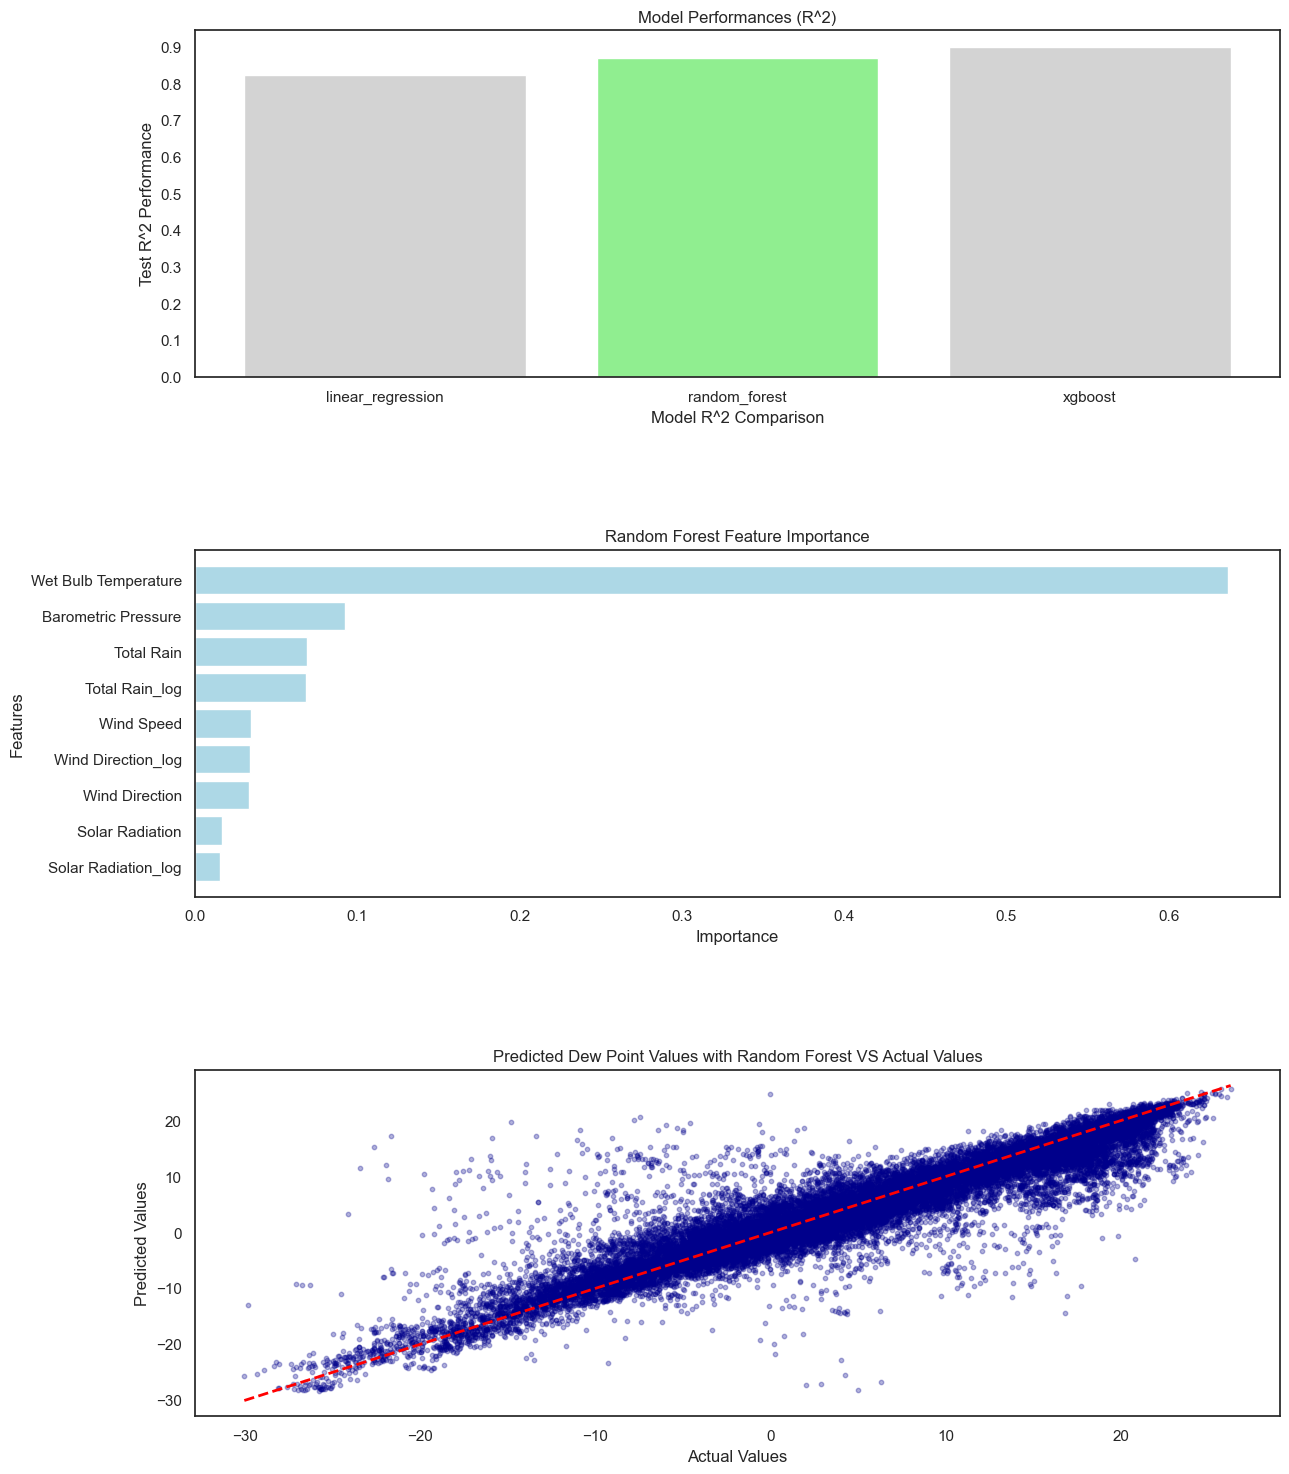

<Figure size 1000x600 with 0 Axes>

In [83]:
# create visuals comparing model performance metrics

# r squared performance visual
sns.set_theme(style="white")
fig, axes = plt.subplots(3, 1, figsize=(14, 18))

fig.subplots_adjust(hspace=0.5)

model_r2_performance = metrics_df.iloc[1]
axes[0].bar(
    model_r2_performance.index,
    model_r2_performance.values,
    color=['lightgrey', 'lightgreen', 'lightgrey']
)
axes[0].set_title('Model Performances (R^2)')
axes[0].set_ylabel('Test R^2 Performance')
axes[0].set_xlabel('Model R^2 Comparison')
axes[0].set_yticks(np.arange(0,1,0.10))

# feature importance

rf_importance = feature_importance[['feature', 'rf_importance']].dropna()
rf_importance = rf_importance.sort_values('rf_importance')

plt.figure(figsize=(10,6))
axes[1].barh(
    rf_importance['feature'], 
    rf_importance['rf_importance'], 
    color='lightblue'
)
axes[1].set_xlabel('Importance')
axes[1].set_ylabel('Features')
axes[1].set_title('Random Forest Feature Importance')

# random forest prediction plot
axes[2].scatter(
    predictions['actual'],
    predictions['predicted_rf'],
    alpha=0.3, s=10, color='darkblue')
axes[2].plot(
    [predictions['actual'].min(),
     predictions['actual'].max()],
     [predictions['actual'].min(),
      predictions['actual'].max()],
      'r--', color= 'red',linewidth=2)
axes[2].set_title('Predicted Dew Point Values with Random Forest VS Actual Values')
axes[2].set_ylabel('Predicted Values')
axes[2].set_xlabel('Actual Values')

fig.savefig('output/q8_final_visualizations.png', dpi=150)

In [84]:
# key findings txt

top_feature = rf_importance.iloc[-1] 
feature_name = top_feature['feature']
feature_value = top_feature['rf_importance']
raw_data = pd.read_csv('data/beach_sensors.csv')
raw_rows = raw_data.shape[0]
with open('output/q2_rows_cleaned.txt', 'r') as f:
    cleaned_rows = f.read().strip() 
    cleaned_rows = int(cleaned_rows)

with open('output/q8_key_findings.txt', 'w') as f:
    f.write('KEY FINDINGS SUMMARY\n')
    f.write('====================\n')
    f.write(f'- Random forest had the best performing metrics between train and test sets\n')
    f.write(f'- XGBoost and Linear Regression seemed to overfit the data, the training metrics were lower than the test metrics\n')
    f.write(f'- Made me feel weird so I chose to use Random Forest becuause train and test showed a somewhat normal pattern\n\n')
    f.write(f'FEATURE IMPORTANCE\n')
    f.write(f'Most important feature: {feature_name}: {feature_value:.4f}\n\n')
    f.write('TEMPORAL PATTERNS\n')
    f.write(f'- clear seasonal pattern for dew point feature\n\n')
    f.write('DATA QUALITY\n')
    f.write(f'Data cleaned from {raw_rows} rows to {cleaned_rows} rows\n')
    f.write('Missing data handled with forward-fill and mean imputation\n')
    f.write('Outliers capped using IQR')


---

## Objective

Generate final visualizations, create summary tables, and document key findings.

---

## Required Artifacts

You must create exactly these 3 files in the `output/` directory:

### 1. `output/q8_final_visualizations.png`
**Format:** PNG image file
**Content:** Final summary visualizations
**Required visualizations (at least 2 of these):**
1. **Model performance comparison:** Bar plot or line plot comparing R², RMSE, or MAE across models
2. **Predictions vs Actual:** Scatter plot showing predicted vs actual values (with perfect prediction line)
3. **Feature importance:** Bar plot showing top N features by importance
4. **Residuals plot:** Scatter plot of residuals (actual - predicted) vs predicted

**Requirements:**
- Clear axis labels (xlabel, ylabel)
- Title for each subplot
- Overall figure title (optional but recommended)
- Legend if multiple series shown
- Saved as PNG with sufficient resolution (dpi=150 or higher)

### 2. `output/q8_summary.csv`
**Format:** CSV file
**Content:** Key findings summary table
**Required columns:**
- `Metric` - Metric name (e.g., "R² Score", "RMSE", "MAE")
- One column per model (e.g., `Linear Regression`, `Random Forest`, `XGBoost`)

**Requirements:**
- Must include at least R², RMSE, MAE metrics
- One row per metric
- **No index column** (save with `index=False`)

**Example:**
```csv
Metric,Linear Regression,Random Forest,XGBoost
R² Score,-0.0201,0.9705,0.9967
RMSE,12.7154,2.1634,0.7276
MAE,9.8468,1.3545,0.4480
```

### 3. `output/q8_key_findings.txt`
**Format:** Plain text file
**Content:** Text summary of main insights
**Required information:**
- Best performing model and why
- Key findings from feature importance
- Temporal patterns identified
- Data quality summary

**Example format:**
```
KEY FINDINGS SUMMARY
===================

MODEL PERFORMANCE:
- Best performing model: XGBoost (R² = 0.9967)
- All models show reasonable performance (R² > 0.7 for tree-based models)
- XGBoost achieves lowest RMSE: 0.73°C

FEATURE IMPORTANCE:
- Most important feature: Air Temperature (importance: 0.6539)
- Top 3 features account for 93.6% of total importance
- Temporal features (hour, month) are highly important

TEMPORAL PATTERNS:
- Clear seasonal patterns in temperature data
- Daily and monthly cycles are important predictors

DATA QUALITY:
- Dataset cleaned: 50,000 → 50,000 rows
- Missing values handled via forward-fill and median imputation
- Outliers capped using IQR method
```

---

## Requirements Checklist

- [ ] Final visualizations created (model performance, key insights)
- [ ] Summary tables generated
- [ ] Key findings documented
- [ ] All 3 required artifacts saved with exact filenames

---

## Your Approach

1. **Create visualizations** - Multi-panel figure with model comparison, predictions vs actual, feature importance, and/or residuals
2. **Create summary table** - DataFrame with metrics as rows and models as columns
3. **Document key findings** - Text summary covering model performance, feature importance insights, temporal patterns, and data quality notes

---

## Decision Points

- **Visualizations:** What best communicates your findings? Model performance plots? Time series with predictions? Feature importance plots?
- **Summary:** What are the key takeaways? Document the most important findings from your analysis.

---

## Checkpoint

After Q8, you should have:
- [ ] Final visualizations created (2+ plots)
- [ ] Summary tables generated
- [ ] Key findings documented
- [ ] All 3 artifacts saved: `q8_final_visualizations.png`, `q8_summary.csv`, `q8_key_findings.txt`

---

**Next:** Continue to `q9_writeup.md` for Writeup.
